# Feature Importance

In [17]:
from xgboost import XGBRegressor
from xgboost import plot_importance, plot_tree
# print(xgboost.__version__)


import pandas as pd
import numpy as np
import json

import sys
sys.path.append("C:/Users/mchiu/OneDrive/mch/Work/TheCompany/Development/src/python/mch/")

from LibPub.DataSetManager import DataSet

from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
pred_ds = DataSet()
pred_ds.open_dataset("./data/PRED@AdaBoost_CANDLE_AUDUSD_H1_Bid_EMA_5.json")

train_ds = DataSet()
train_ds.open_dataset("./data/TRAIN@AdaBoost_CANDLE_AUDUSD_H1_Bid_EMA_5")

In [3]:
# create an xgboost regression model

model = XGBRegressor(n_estimators=100, 
                             max_depth=10, 
                             eta=0.5, 
                             subsample=1, 
                             colsample_bytree=1,
                             reg_alpha=0.00001,
                             reg_lambda=0.01)



In [7]:
X = train_ds.data[train_ds.metadata["features"]]
y = train_ds.data[train_ds.metadata["labels"]["target"]]


X_p = pred_ds.data[train_ds.metadata["features"]]
y_true = pred_ds.data[train_ds.metadata["labels"]["target"]]

In [8]:
model.fit(X,y)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, eta=0.5, gamma=0,
             gpu_id=-1, importance_type='gain', interaction_constraints='',
             learning_rate=0.5, max_delta_step=0, max_depth=10,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=100, n_jobs=8, num_parallel_tree=1, random_state=0,
             reg_alpha=1e-05, reg_lambda=0.01, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

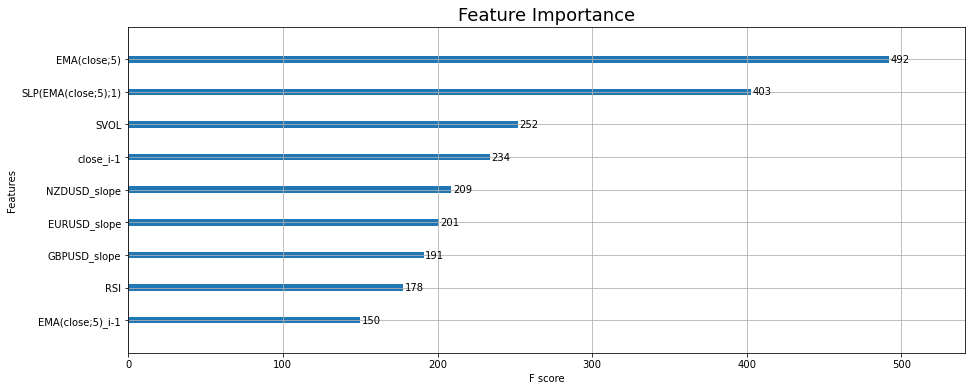

In [26]:
fig, ax = plt.subplots(1,1, figsize=(15,6))
_ = plot_importance(model.get_booster().get_score(importance_type='weight'), ax=ax)
plt.title('Feature Importance', size=18)
plt.show()